# Subject-Independent EEG Emotion Recognition
## Comparative Analysis of DGCNN and Random Forest Models under EEG Channel Reduction

### Objective

This notebook compares three subject-independent EEG emotion recognition approaches:

1. DGCNN using EEG signal representations
2. Random Forest using Mean + Variance features
3. Random Forest using Band-Power features

The models are evaluated across:

- Valence
- Arousal
- Dominance
- Liking

Each model is evaluated using:

- 32 channels
- 16 channels
- 8 channels
- 4 channels

The primary objective is to investigate:

1. Which model provides the best subject-independent generalization?
2. How does EEG channel reduction affect performance?
3. Does the optimal channel count depend on the emotion?
4. Do handcrafted features outperform graph-based deep learning under the current experimental conditions?
5. Can comparable performance be maintained using fewer EEG channels?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
dgcnn_results = pd.DataFrame([
    ["Valence", 32, 0.5536, 0.5372, 0.5520, 0.8243, 0.6612, 0.5309, 0.5202],
    ["Valence", 16, 0.5357, 0.5305, 0.5542, 0.6216, 0.5860, 0.5306, 0.5159],
    ["Valence", 8,  0.5464, 0.5292, 0.5467, 0.8311, 0.6595, 0.5005, 0.5128],
    ["Valence", 4,  0.5321, 0.5243, 0.5475, 0.6622, 0.5994, 0.5329, 0.5149],

    ["Arousal", 32, 0.5286, 0.4833, 0.5546, 0.8354, 0.6667, 0.4774, 0.5286],
    ["Arousal", 16, 0.4500, 0.4566, 0.5161, 0.4051, 0.4539, 0.4685, 0.4710],
    ["Arousal", 8,  0.4643, 0.4506, 0.5238, 0.5570, 0.5399, 0.4874, 0.4940],
    ["Arousal", 4,  0.5143, 0.4874, 0.5556, 0.6962, 0.6180, 0.5095, 0.5313],

    ["Dominance", 32, 0.5143, 0.5097, 0.6301, 0.5287, 0.5750, 0.4827, 0.4986],
    ["Dominance", 16, 0.4071, 0.3939, 0.5270, 0.4483, 0.4845, 0.4088, 0.4697],
    ["Dominance", 8,  0.3286, 0.4100, 0.3250, 0.0747, 0.1215, 0.3491, 0.3869],
    ["Dominance", 4,  0.4536, 0.4516, 0.5755, 0.4598, 0.5112, 0.3996, 0.4577],

    ["Liking", 32, 0.5714, 0.4725, 0.6208, 0.8371, 0.7129, 0.4458, 0.5561],
    ["Liking", 16, 0.5786, 0.4969, 0.6339, 0.7978, 0.7065, 0.5377, 0.5563],
    ["Liking", 8,  0.5679, 0.4738, 0.6213, 0.8202, 0.7070, 0.4982, 0.5720],
    ["Liking", 4,  0.5643, 0.4647, 0.6167, 0.8315, 0.7081, 0.4823, 0.5388],
], columns=[
    "Emotion",
    "Channels",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Window Accuracy"
])

dgcnn_results["Model"] = "DGCNN"

display(dgcnn_results)

,Emotion,Channels,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC,Window Accuracy,Model
0,Valence,32,0.5536,0.5372,0.5520,0.8243,0.6612,0.5309,0.5202,DGCNN
1,Valence,16,0.5357,0.5305,0.5542,0.6216,0.5860,0.5306,0.5159,DGCNN
2,Valence,8,0.5464,0.5292,0.5467,0.8311,0.6595,0.5005,0.5128,DGCNN
3,Valence,4,0.5321,0.5243,0.5475,0.6622,0.5994,0.5329,0.5149,DGCNN
4,Arousal,32,0.5286,0.4833,0.5546,0.8354,0.6667,0.4774,0.5286,DGCNN
5,Arousal,16,0.4500,0.4566,0.5161,0.4051,0.4539,0.4685,0.4710,DGCNN
6,Arousal,8,0.4643,0.4506,0.5238,0.5570,0.5399,0.4874,0.4940,DGCNN
7,Arousal,4,0.5143,0.4874,0.5556,0.6962,0.6180,0.5095,0.5313,DGCNN
8,Dominance,32,0.5143,0.5097,0.6301,0.5287,0.5750,0.4827,0.4986,DGCNN
9,Dominance,16,0.4071,0.3939,0.5270,0.4483,0.4845,0.4088,0.4697,DGCNN


In [4]:
rf_mv_results = pd.DataFrame([
    ["Valence", 32, 0.4571, 0.4414, 0.4907, 0.7162, 0.5824, 0.4609],
    ["Valence", 16, 0.5679, 0.5462, 0.5547, 0.9257, 0.6937, 0.6046],
    ["Valence", 8,  0.5143, 0.4922, 0.5242, 0.8784, 0.6566, 0.4794],
    ["Valence", 4,  0.4786, 0.4601, 0.5043, 0.7838, 0.6138, 0.4885],

    ["Arousal", 32, 0.5000, 0.4813, 0.5500, 0.6266, 0.5858, 0.4630],
    ["Arousal", 16, 0.5143, 0.5015, 0.5655, 0.6013, 0.5828, 0.4767],
    ["Arousal", 8,  0.4964, 0.4875, 0.5535, 0.5570, 0.5552, 0.4685],
    ["Arousal", 4,  0.4714, 0.4588, 0.5301, 0.5570, 0.5432, 0.4544],

    ["Dominance", 32, 0.5929, 0.4954, 0.6190, 0.8966, 0.7089, 0.4273],
    ["Dominance", 16, 0.5571, 0.4575, 0.5992, 0.8678, 0.7089, 0.4868],
    ["Dominance", 8,  0.5286, 0.4419, 0.5890, 0.7989, 0.6780, 0.3685],
    ["Dominance", 4,  0.5036, 0.4494, 0.5879, 0.6724, 0.6273, 0.3671],

    ["Liking", 32, 0.6357, 0.5000, 0.6357, 1.0000, 0.7773, 0.4474],
    ["Liking", 16, 0.6286, 0.4944, 0.6331, 0.9888, 0.7719, 0.5611],
    ["Liking", 8,  0.6214, 0.4909, 0.6314, 0.9719, 0.7655, 0.5358],
    ["Liking", 4,  0.6071, 0.4943, 0.6328, 0.9101, 0.7465, 0.5047],
], columns=[
    "Emotion",
    "Channels",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
])

rf_mv_results["Model"] = "RF - Mean + Variance"

display(rf_mv_results)

,Emotion,Channels,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC,Model
0,Valence,32,0.4571,0.4414,0.4907,0.7162,0.5824,0.4609,RF - Mean + Variance
1,Valence,16,0.5679,0.5462,0.5547,0.9257,0.6937,0.6046,RF - Mean + Variance
2,Valence,8,0.5143,0.4922,0.5242,0.8784,0.6566,0.4794,RF - Mean + Variance
3,Valence,4,0.4786,0.4601,0.5043,0.7838,0.6138,0.4885,RF - Mean + Variance
4,Arousal,32,0.5000,0.4813,0.5500,0.6266,0.5858,0.4630,RF - Mean + Variance
5,Arousal,16,0.5143,0.5015,0.5655,0.6013,0.5828,0.4767,RF - Mean + Variance
6,Arousal,8,0.4964,0.4875,0.5535,0.5570,0.5552,0.4685,RF - Mean + Variance
7,Arousal,4,0.4714,0.4588,0.5301,0.5570,0.5432,0.4544,RF - Mean + Variance
8,Dominance,32,0.5929,0.4954,0.6190,0.8966,0.7089,0.4273,RF - Mean + Variance
9,Dominance,16,0.5571,0.4575,0.5992,0.8678,0.7089,0.4868,RF - Mean + Variance


In [5]:
rf_band_results = pd.DataFrame([
    ["Valence", 32, 0.4571, 0.4414, 0.4907, 0.7162, 0.5824, 0.4609],
    ["Valence", 16, 0.5214, 0.5092, 0.5350, 0.7230, 0.6149, 0.4973],
    ["Valence", 8,  0.5357, 0.5113, 0.5346, 0.9392, 0.6814, 0.5503],
    ["Valence", 4,  0.5250, 0.5069, 0.5328, 0.8243, 0.6472, 0.5691],

    ["Arousal", 32, 0.5357, 0.5111, 0.5722, 0.7025, 0.6307, 0.5377],
    ["Arousal", 16, 0.4500, 0.4389, 0.5123, 0.5253, 0.5188, 0.4341],
    ["Arousal", 8,  0.4964, 0.4828, 0.5503, 0.5886, 0.5688, 0.4752],
    ["Arousal", 4,  0.5321, 0.5238, 0.5849, 0.5886, 0.5868, 0.5020],

    ["Dominance", 32, 0.5929, 0.5028, 0.6230, 0.8736, 0.7273, 0.4454],
    ["Dominance", 16, 0.5500, 0.4720, 0.6053, 0.7931, 0.6866, 0.4183],
    ["Dominance", 8,  0.5893, 0.5202, 0.6335, 0.8046, 0.7089, 0.4641],
    ["Dominance", 4,  0.5179, 0.4738, 0.6032, 0.6552, 0.6281, 0.4140],

    ["Liking", 32, 0.6357, 0.5000, 0.6357, 1.0000, 0.7773, 0.4337],
    ["Liking", 16, 0.6321, 0.4972, 0.6344, 0.9944, 0.7746, 0.5351],
    ["Liking", 8,  0.6393, 0.5112, 0.6410, 0.9831, 0.7761, 0.5348],
    ["Liking", 4,  0.6071, 0.4838, 0.6278, 0.9382, 0.7523, 0.5300],
], columns=[
    "Emotion",
    "Channels",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
])

rf_band_results["Model"] = "RF - Band Power"

display(rf_band_results)

,Emotion,Channels,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC,Model
0,Valence,32,0.4571,0.4414,0.4907,0.7162,0.5824,0.4609,RF - Band Power
1,Valence,16,0.5214,0.5092,0.5350,0.7230,0.6149,0.4973,RF - Band Power
2,Valence,8,0.5357,0.5113,0.5346,0.9392,0.6814,0.5503,RF - Band Power
3,Valence,4,0.5250,0.5069,0.5328,0.8243,0.6472,0.5691,RF - Band Power
4,Arousal,32,0.5357,0.5111,0.5722,0.7025,0.6307,0.5377,RF - Band Power
5,Arousal,16,0.4500,0.4389,0.5123,0.5253,0.5188,0.4341,RF - Band Power
6,Arousal,8,0.4964,0.4828,0.5503,0.5886,0.5688,0.4752,RF - Band Power
7,Arousal,4,0.5321,0.5238,0.5849,0.5886,0.5868,0.5020,RF - Band Power
8,Dominance,32,0.5929,0.5028,0.6230,0.8736,0.7273,0.4454,RF - Band Power
9,Dominance,16,0.5500,0.4720,0.6053,0.7931,0.6866,0.4183,RF - Band Power


In [6]:
comparison_df = pd.concat(
    [
        dgcnn_results,
        rf_mv_results,
        rf_band_results
    ],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    ["Emotion", "Channels", "Model"]
).reset_index(drop=True)

display(comparison_df)

,Emotion,Channels,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC,Window Accuracy,Model
0,Arousal,4,0.5143,0.4874,0.5556,0.6962,0.6180,0.5095,0.5313,DGCNN
1,Arousal,4,0.5321,0.5238,0.5849,0.5886,0.5868,0.5020,NaN,RF - Band Power
2,Arousal,4,0.4714,0.4588,0.5301,0.5570,0.5432,0.4544,NaN,RF - Mean + Variance
3,Arousal,8,0.4643,0.4506,0.5238,0.5570,0.5399,0.4874,0.4940,DGCNN
4,Arousal,8,0.4964,0.4828,0.5503,0.5886,0.5688,0.4752,NaN,RF - Band Power
5,Arousal,8,0.4964,0.4875,0.5535,0.5570,0.5552,0.4685,NaN,RF - Mean + Variance
6,Arousal,16,0.4500,0.4566,0.5161,0.4051,0.4539,0.4685,0.4710,DGCNN
7,Arousal,16,0.4500,0.4389,0.5123,0.5253,0.5188,0.4341,NaN,RF - Band Power
8,Arousal,16,0.5143,0.5015,0.5655,0.6013,0.5828,0.4767,NaN,RF - Mean + Variance
9,Arousal,32,0.5286,0.4833,0.5546,0.8354,0.6667,0.4774,0.5286,DGCNN


In [7]:
print("Total configurations:", len(comparison_df))
print("Models:", comparison_df["Model"].unique())
print("Emotions:", comparison_df["Emotion"].unique())
print("Channel configurations:", sorted(comparison_df["Channels"].unique()))

Total configurations: 48
Models: ['DGCNN' 'RF - Band Power' 'RF - Mean + Variance']
Emotions: ['Arousal' 'Dominance' 'Liking' 'Valence']
Channel configurations: [np.int64(4), np.int64(8), np.int64(16), np.int64(32)]


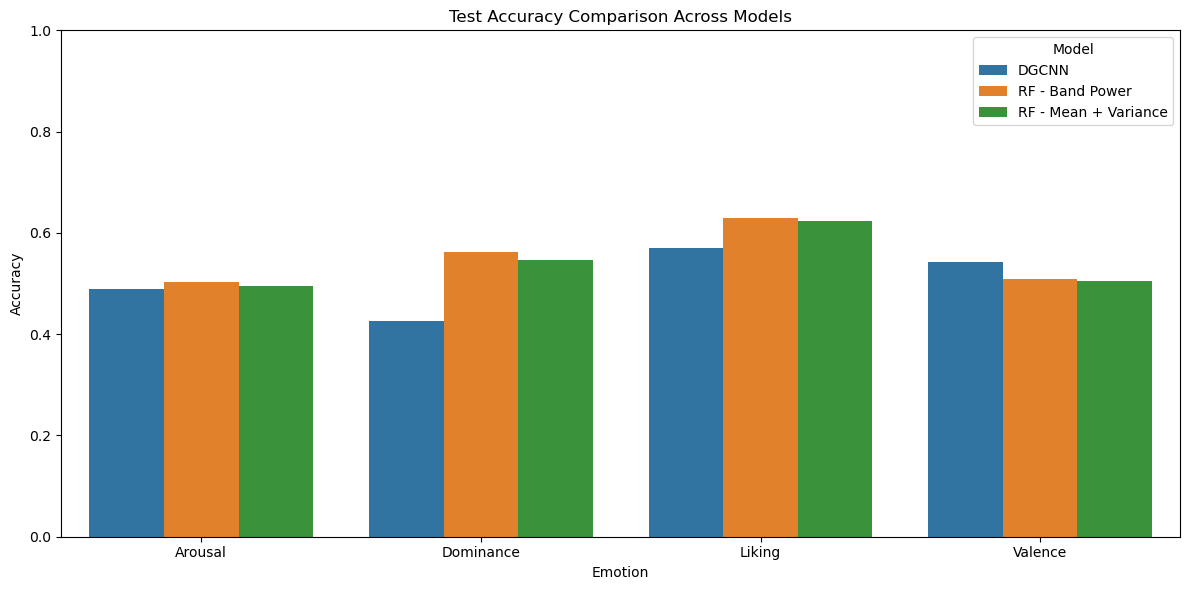

In [8]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_df,
    x="Emotion",
    y="Accuracy",
    hue="Model",
    errorbar=None
)

plt.title("Test Accuracy Comparison Across Models")
plt.ylabel("Accuracy")
plt.xlabel("Emotion")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

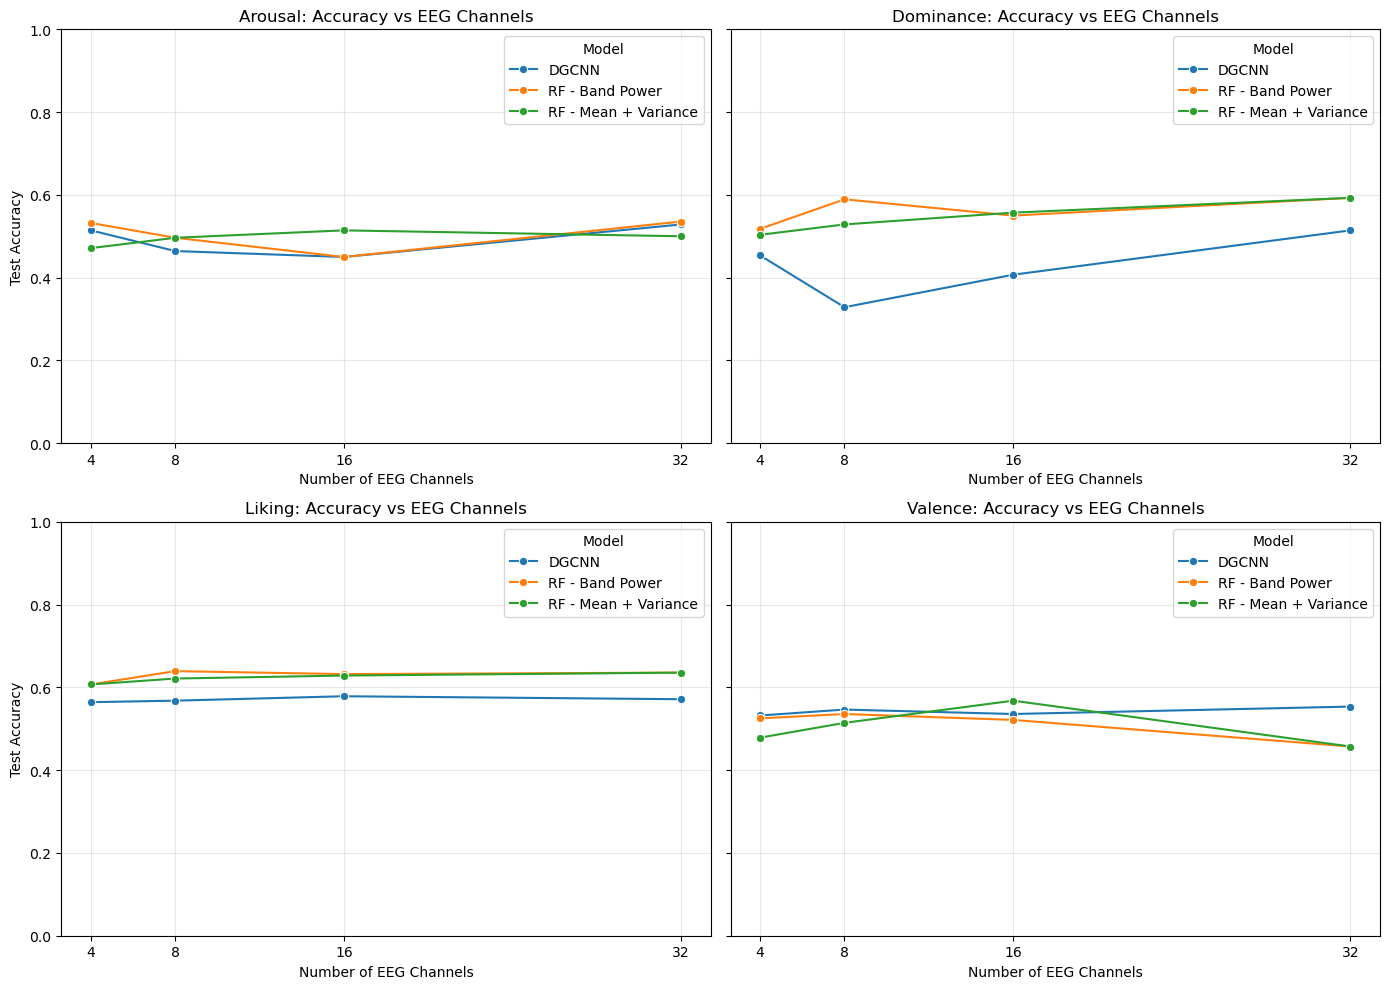

In [9]:
emotions = comparison_df["Emotion"].unique()

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharey=True
)

axes = axes.flatten()

for ax, emotion in zip(axes, emotions):

    subset = comparison_df[
        comparison_df["Emotion"] == emotion
    ]

    sns.lineplot(
        data=subset,
        x="Channels",
        y="Accuracy",
        hue="Model",
        marker="o",
        ax=ax
    )

    ax.set_title(f"{emotion}: Accuracy vs EEG Channels")
    ax.set_xlabel("Number of EEG Channels")
    ax.set_ylabel("Test Accuracy")
    ax.set_xticks([4, 8, 16, 32])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

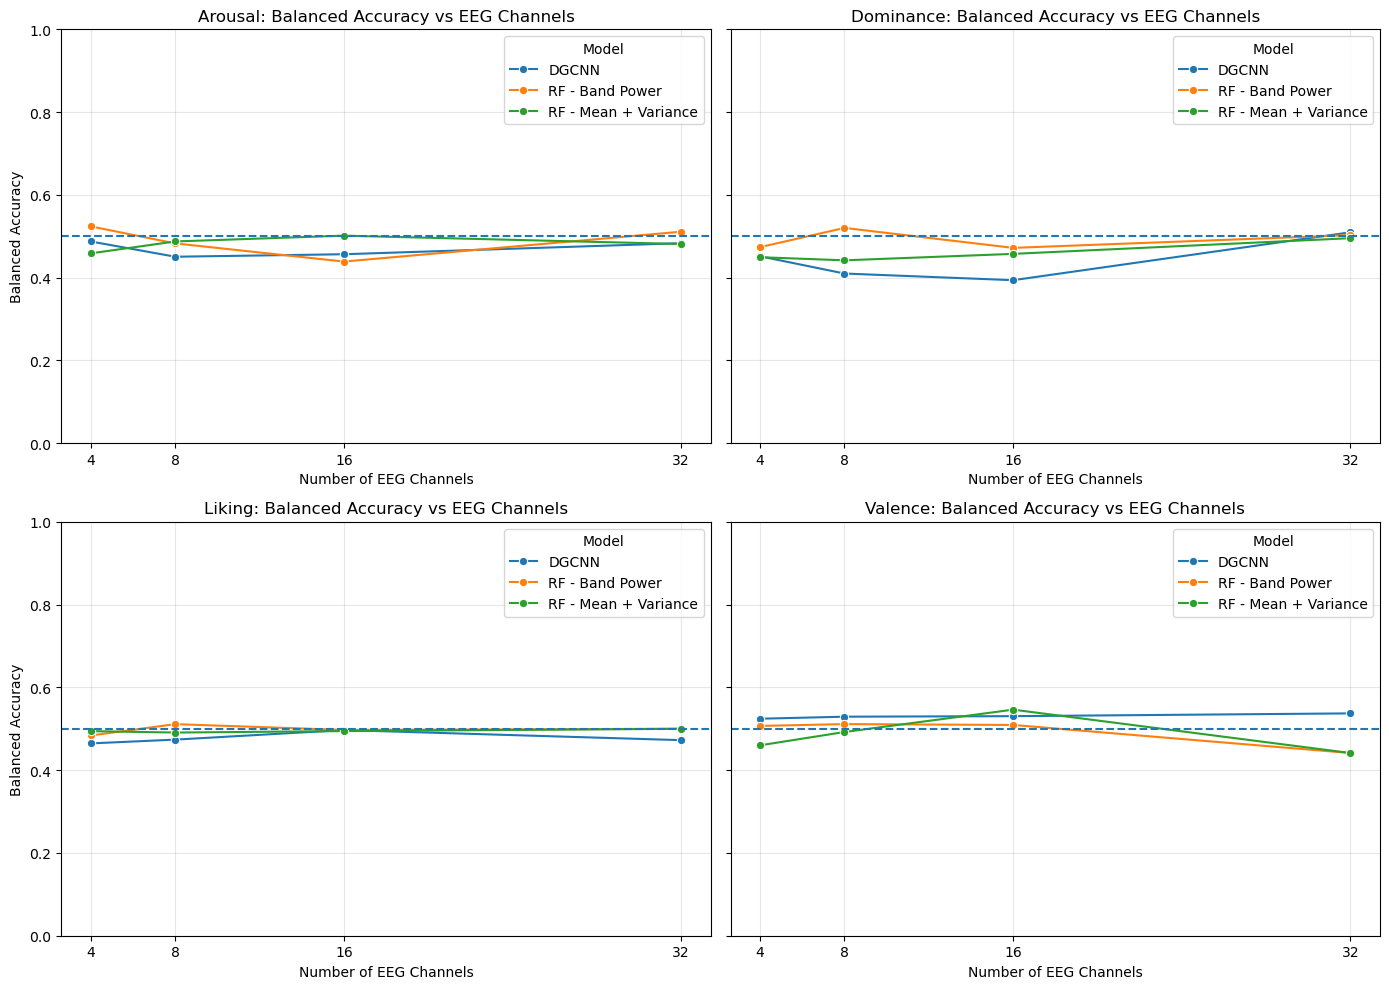

In [10]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharey=True
)

axes = axes.flatten()

for ax, emotion in zip(axes, emotions):

    subset = comparison_df[
        comparison_df["Emotion"] == emotion
    ]

    sns.lineplot(
        data=subset,
        x="Channels",
        y="Balanced Accuracy",
        hue="Model",
        marker="o",
        ax=ax
    )

    ax.axhline(
        0.5,
        linestyle="--",
        label="Chance Level"
    )

    ax.set_title(
        f"{emotion}: Balanced Accuracy vs EEG Channels"
    )

    ax.set_xlabel("Number of EEG Channels")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_xticks([4, 8, 16, 32])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

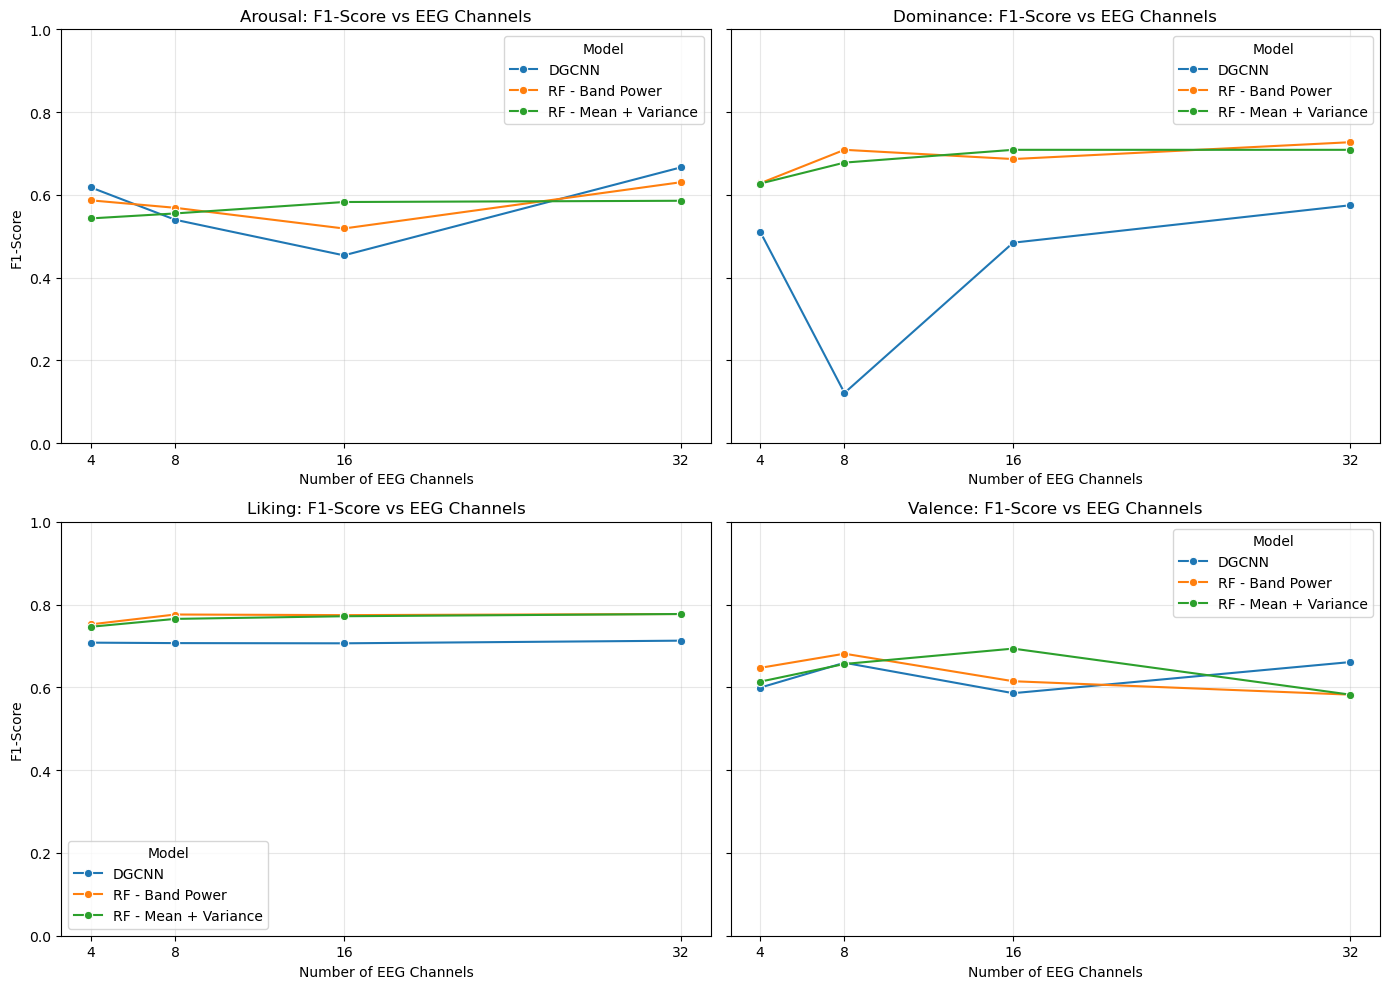

In [11]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharey=True
)

axes = axes.flatten()

for ax, emotion in zip(axes, emotions):

    subset = comparison_df[
        comparison_df["Emotion"] == emotion
    ]

    sns.lineplot(
        data=subset,
        x="Channels",
        y="F1-Score",
        hue="Model",
        marker="o",
        ax=ax
    )

    ax.set_title(
        f"{emotion}: F1-Score vs EEG Channels"
    )

    ax.set_xlabel("Number of EEG Channels")
    ax.set_ylabel("F1-Score")
    ax.set_xticks([4, 8, 16, 32])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

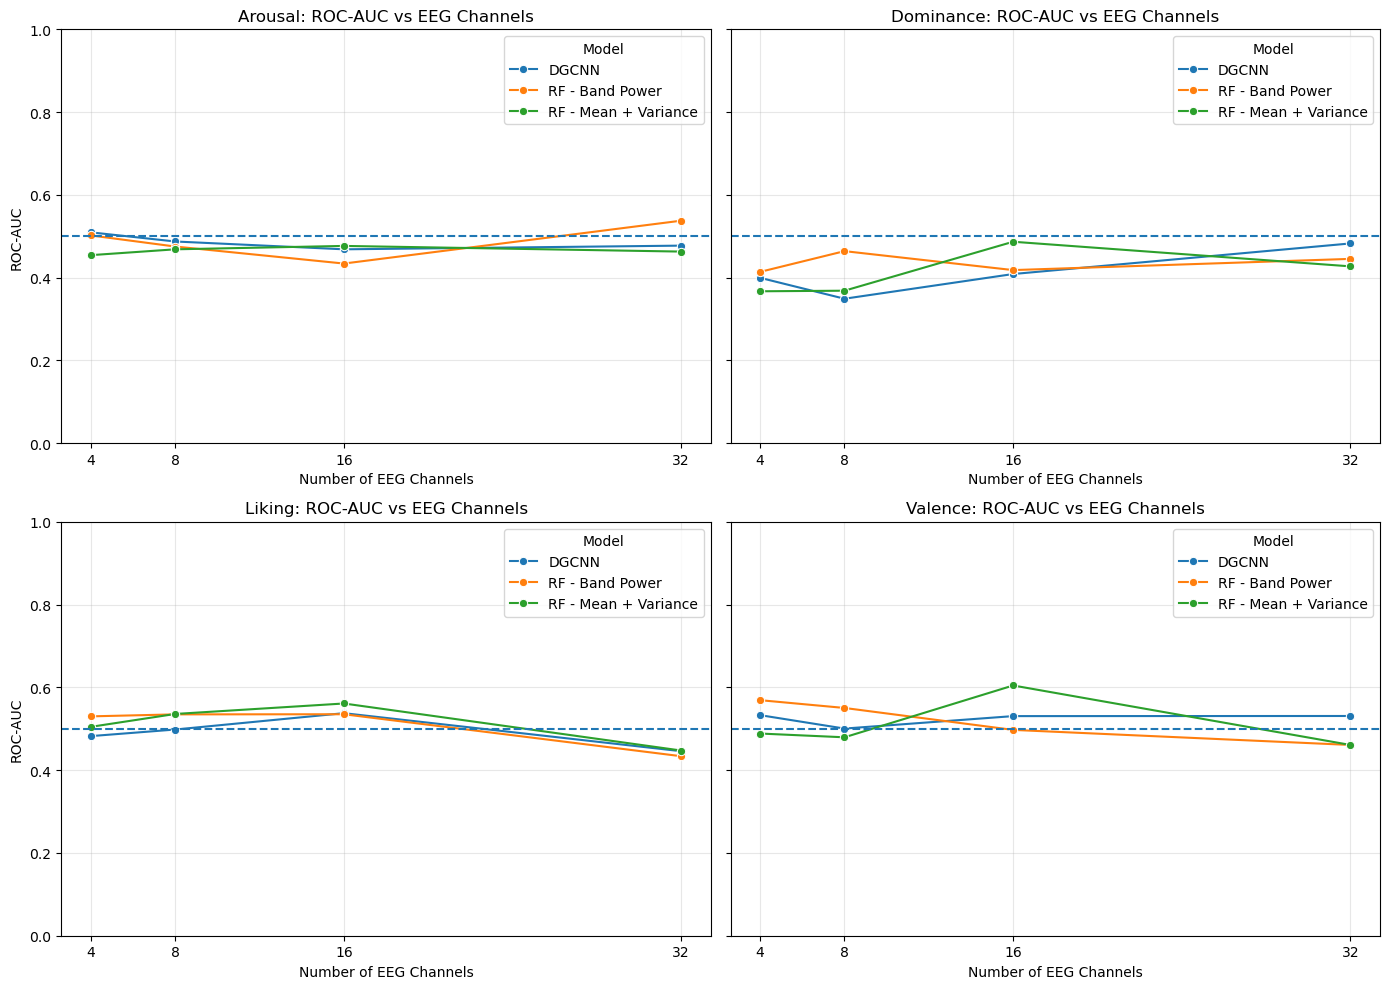

In [12]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharey=True
)

axes = axes.flatten()

for ax, emotion in zip(axes, emotions):

    subset = comparison_df[
        comparison_df["Emotion"] == emotion
    ]

    sns.lineplot(
        data=subset,
        x="Channels",
        y="ROC-AUC",
        hue="Model",
        marker="o",
        ax=ax
    )

    ax.axhline(
        0.5,
        linestyle="--",
        label="Random Classifier"
    )

    ax.set_title(
        f"{emotion}: ROC-AUC vs EEG Channels"
    )

    ax.set_xlabel("Number of EEG Channels")
    ax.set_ylabel("ROC-AUC")
    ax.set_xticks([4, 8, 16, 32])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
best_accuracy = (
    comparison_df
    .loc[
        comparison_df.groupby("Emotion")["Accuracy"]
        .idxmax()
    ]
    .sort_values("Emotion")
)

print("BEST CONFIGURATION BY TEST ACCURACY")
display(
    best_accuracy[
        [
            "Emotion",
            "Model",
            "Channels",
            "Accuracy",
            "Balanced Accuracy",
            "F1-Score",
            "ROC-AUC"
        ]
    ]
)

BEST CONFIGURATION BY TEST ACCURACY


,Emotion,Model,Channels,Accuracy,Balanced Accuracy,F1-Score,ROC-AUC
10,Arousal,RF - Band Power,32,0.5357,0.5111,0.6307,0.5377
22,Dominance,RF - Band Power,32,0.5929,0.5028,0.7273,0.4454
28,Liking,RF - Band Power,8,0.6393,0.5112,0.7761,0.5348
44,Valence,RF - Mean + Variance,16,0.5679,0.5462,0.6937,0.6046


In [14]:
best_balanced_accuracy = (
    comparison_df
    .loc[
        comparison_df.groupby("Emotion")["Balanced Accuracy"]
        .idxmax()
    ]
    .sort_values("Emotion")
)

print("BEST CONFIGURATION BY BALANCED ACCURACY")
display(
    best_balanced_accuracy[
        [
            "Emotion",
            "Model",
            "Channels",
            "Accuracy",
            "Balanced Accuracy",
            "F1-Score",
            "ROC-AUC"
        ]
    ]
)

BEST CONFIGURATION BY BALANCED ACCURACY


,Emotion,Model,Channels,Accuracy,Balanced Accuracy,F1-Score,ROC-AUC
1,Arousal,RF - Band Power,4,0.5321,0.5238,0.5868,0.5020
16,Dominance,RF - Band Power,8,0.5893,0.5202,0.7089,0.4641
28,Liking,RF - Band Power,8,0.6393,0.5112,0.7761,0.5348
44,Valence,RF - Mean + Variance,16,0.5679,0.5462,0.6937,0.6046


In [15]:
best_roc_auc = (
    comparison_df
    .loc[
        comparison_df.groupby("Emotion")["ROC-AUC"]
        .idxmax()
    ]
    .sort_values("Emotion")
)

print("BEST CONFIGURATION BY ROC-AUC")
display(
    best_roc_auc[
        [
            "Emotion",
            "Model",
            "Channels",
            "Accuracy",
            "Balanced Accuracy",
            "F1-Score",
            "ROC-AUC"
        ]
    ]
)

BEST CONFIGURATION BY ROC-AUC


,Emotion,Model,Channels,Accuracy,Balanced Accuracy,F1-Score,ROC-AUC
10,Arousal,RF - Band Power,32,0.5357,0.5111,0.6307,0.5377
20,Dominance,RF - Mean + Variance,16,0.5571,0.4575,0.7089,0.4868
32,Liking,RF - Mean + Variance,16,0.6286,0.4944,0.7719,0.5611
44,Valence,RF - Mean + Variance,16,0.5679,0.5462,0.6937,0.6046


In [16]:
model_summary = (
    comparison_df
    .groupby("Model")
    [
        [
            "Accuracy",
            "Balanced Accuracy",
            "F1-Score",
            "ROC-AUC"
        ]
    ]
    .mean()
    .sort_values(
        "Balanced Accuracy",
        ascending=False
    )
)

display(model_summary)

,Accuracy,Balanced Accuracy,F1-Score,ROC-AUC
Model,,,,
RF - Band Power,0.5511,0.4929,0.6664,0.4876
RF - Mean + Variance,0.5422,0.4808,0.6624,0.4747
DGCNN,0.5069,0.4795,0.5820,0.4776


In [17]:
emotion_summary = (
    comparison_df
    .groupby(["Emotion", "Model"])
    [
        [
            "Accuracy",
            "Balanced Accuracy",
            "F1-Score",
            "ROC-AUC"
        ]
    ]
    .mean()
    .reset_index()
)

display(emotion_summary)

,Emotion,Model,Accuracy,Balanced Accuracy,F1-Score,ROC-AUC
0,Arousal,DGCNN,0.4893,0.4695,0.5696,0.4857
1,Arousal,RF - Band Power,0.5035,0.4892,0.5763,0.4872
2,Arousal,RF - Mean + Variance,0.4955,0.4823,0.5667,0.4657
3,Dominance,DGCNN,0.4259,0.4413,0.4230,0.4101
4,Dominance,RF - Band Power,0.5625,0.4922,0.6877,0.4355
5,Dominance,RF - Mean + Variance,0.5455,0.4611,0.6808,0.4124
6,Liking,DGCNN,0.5706,0.4770,0.7086,0.4910
7,Liking,RF - Band Power,0.6285,0.4980,0.7701,0.5084
8,Liking,RF - Mean + Variance,0.6232,0.4949,0.7653,0.5123
9,Valence,DGCNN,0.5419,0.5303,0.6265,0.5237


In [18]:
stability_df = comparison_df.pivot_table(
    index=["Emotion", "Model"],
    columns="Channels",
    values="Accuracy"
).reset_index()

stability_df["Accuracy Change (32 → 4)"] = (
    stability_df[4] - stability_df[32]
)

stability_df["Absolute Performance Loss"] = (
    abs(stability_df["Accuracy Change (32 → 4)"])
)

display(stability_df)

Channels,Emotion,Model,4,8,16,32,Accuracy Change (32 → 4),Absolute Performance Loss
0,Arousal,DGCNN,0.5143,0.4643,0.4500,0.5286,-0.0143,0.0143
1,Arousal,RF - Band Power,0.5321,0.4964,0.4500,0.5357,-0.0036,0.0036
2,Arousal,RF - Mean + Variance,0.4714,0.4964,0.5143,0.5000,-0.0286,0.0286
3,Dominance,DGCNN,0.4536,0.3286,0.4071,0.5143,-0.0607,0.0607
4,Dominance,RF - Band Power,0.5179,0.5893,0.5500,0.5929,-0.0750,0.0750
5,Dominance,RF - Mean + Variance,0.5036,0.5286,0.5571,0.5929,-0.0893,0.0893
6,Liking,DGCNN,0.5643,0.5679,0.5786,0.5714,-0.0071,0.0071
7,Liking,RF - Band Power,0.6071,0.6393,0.6321,0.6357,-0.0286,0.0286
8,Liking,RF - Mean + Variance,0.6071,0.6214,0.6286,0.6357,-0.0286,0.0286
9,Valence,DGCNN,0.5321,0.5464,0.5357,0.5536,-0.0215,0.0215


In [19]:
stability_df["Percentage Change"] = (
    (stability_df[4] - stability_df[32])
    / stability_df[32]
) * 100

display(stability_df)

Channels,Emotion,Model,4,8,16,32,Accuracy Change (32 → 4),Absolute Performance Loss,Percentage Change
0,Arousal,DGCNN,0.5143,0.4643,0.4500,0.5286,-0.0143,0.0143,-2.7053
1,Arousal,RF - Band Power,0.5321,0.4964,0.4500,0.5357,-0.0036,0.0036,-0.6720
2,Arousal,RF - Mean + Variance,0.4714,0.4964,0.5143,0.5000,-0.0286,0.0286,-5.7200
3,Dominance,DGCNN,0.4536,0.3286,0.4071,0.5143,-0.0607,0.0607,-11.8024
4,Dominance,RF - Band Power,0.5179,0.5893,0.5500,0.5929,-0.0750,0.0750,-12.6497
5,Dominance,RF - Mean + Variance,0.5036,0.5286,0.5571,0.5929,-0.0893,0.0893,-15.0616
6,Liking,DGCNN,0.5643,0.5679,0.5786,0.5714,-0.0071,0.0071,-1.2426
7,Liking,RF - Band Power,0.6071,0.6393,0.6321,0.6357,-0.0286,0.0286,-4.4990
8,Liking,RF - Mean + Variance,0.6071,0.6214,0.6286,0.6357,-0.0286,0.0286,-4.4990
9,Valence,DGCNN,0.5321,0.5464,0.5357,0.5536,-0.0215,0.0215,-3.8837


In [20]:
reduced_channel_df = comparison_df[
    comparison_df["Channels"] <= 8
]

best_reduced = (
    reduced_channel_df
    .loc[
        reduced_channel_df.groupby("Emotion")["Accuracy"]
        .idxmax()
    ]
    .sort_values("Emotion")
)

print("BEST CONFIGURATION USING 8 OR FEWER CHANNELS")

display(
    best_reduced[
        [
            "Emotion",
            "Model",
            "Channels",
            "Accuracy",
            "Balanced Accuracy",
            "F1-Score",
            "ROC-AUC"
        ]
    ]
)

BEST CONFIGURATION USING 8 OR FEWER CHANNELS


,Emotion,Model,Channels,Accuracy,Balanced Accuracy,F1-Score,ROC-AUC
1,Arousal,RF - Band Power,4,0.5321,0.5238,0.5868,0.5020
16,Dominance,RF - Band Power,8,0.5893,0.5202,0.7089,0.4641
28,Liking,RF - Band Power,8,0.6393,0.5112,0.7761,0.5348
39,Valence,DGCNN,8,0.5464,0.5292,0.6595,0.5005


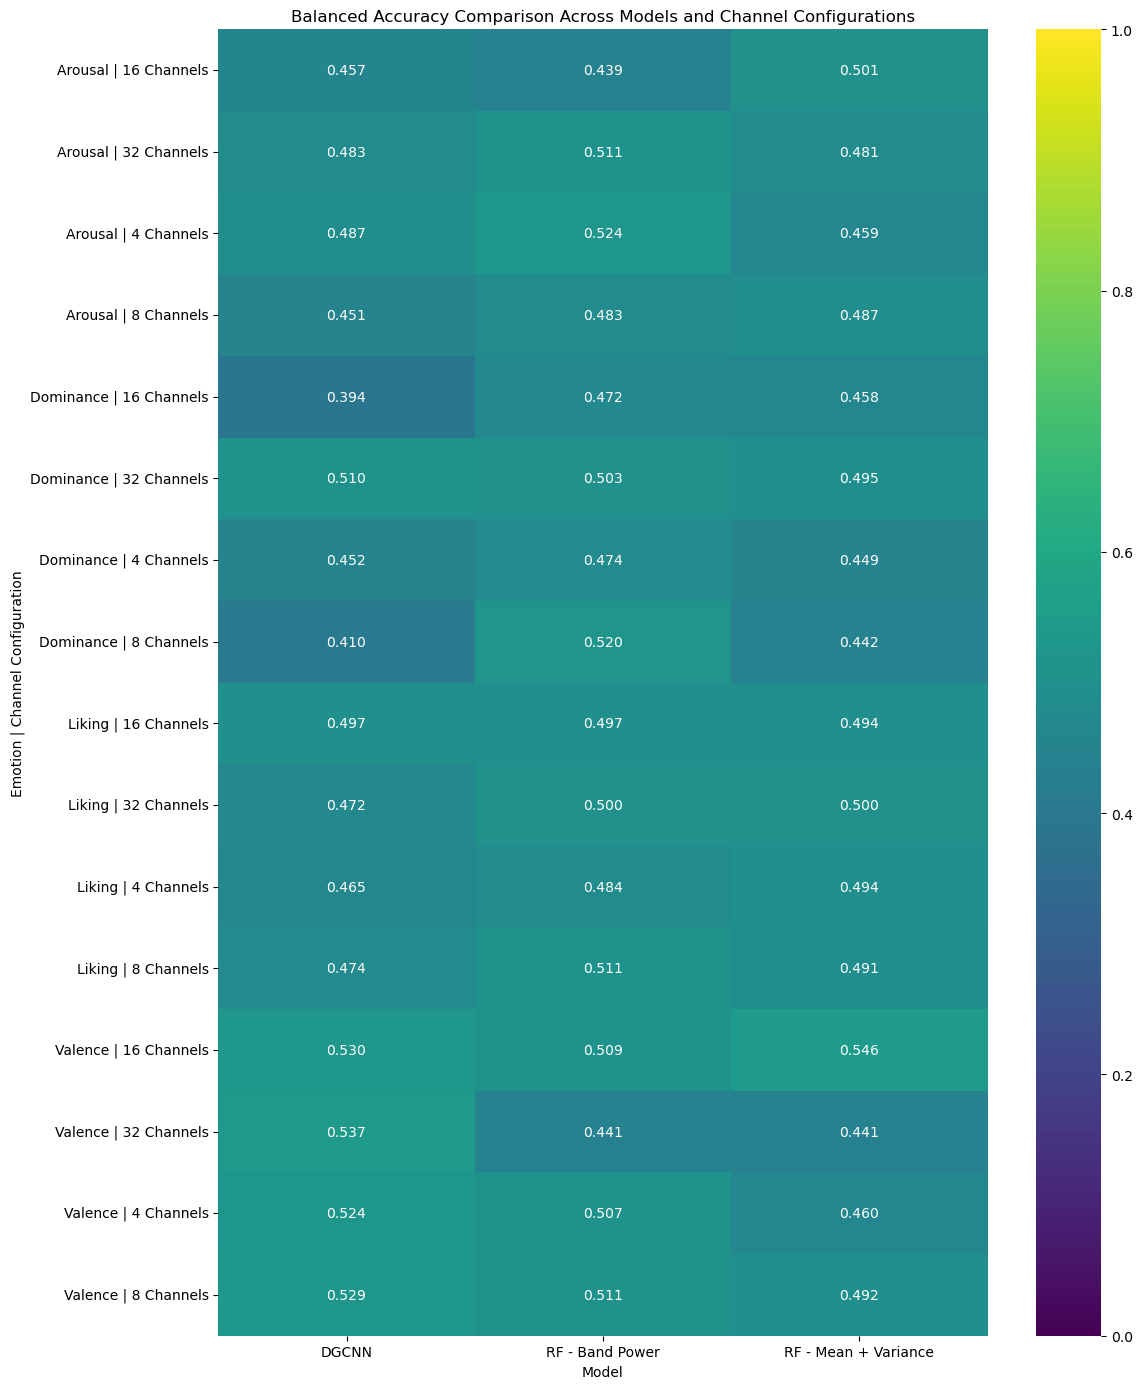

In [21]:
heatmap_df = comparison_df.copy()

heatmap_df["Configuration"] = (
    heatmap_df["Emotion"]
    + " | "
    + heatmap_df["Channels"].astype(str)
    + " Channels"
)

heatmap_data = heatmap_df.pivot_table(
    index="Configuration",
    columns="Model",
    values="Balanced Accuracy"
)

plt.figure(figsize=(12, 14))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.title(
    "Balanced Accuracy Comparison Across Models and Channel Configurations"
)

plt.xlabel("Model")
plt.ylabel("Emotion | Channel Configuration")

plt.tight_layout()
plt.show()

In [22]:
for emotion in emotions:

    subset = comparison_df[
        comparison_df["Emotion"] == emotion
    ]

    best_row = subset.loc[
        subset["Balanced Accuracy"].idxmax()
    ]

    print("=" * 70)
    print(f"Emotion: {emotion}")
    print(f"Best Model: {best_row['Model']}")
    print(f"Channels: {best_row['Channels']}")
    print(
        f"Accuracy: {best_row['Accuracy']:.4f}"
    )
    print(
        f"Balanced Accuracy: "
        f"{best_row['Balanced Accuracy']:.4f}"
    )
    print(
        f"F1-Score: "
        f"{best_row['F1-Score']:.4f}"
    )
    print(
        f"ROC-AUC: "
        f"{best_row['ROC-AUC']:.4f}"
    )

Emotion: Arousal
Best Model: RF - Band Power
Channels: 4
Accuracy: 0.5321
Balanced Accuracy: 0.5238
F1-Score: 0.5868
ROC-AUC: 0.5020
Emotion: Dominance
Best Model: RF - Band Power
Channels: 8
Accuracy: 0.5893
Balanced Accuracy: 0.5202
F1-Score: 0.7089
ROC-AUC: 0.4641
Emotion: Liking
Best Model: RF - Band Power
Channels: 8
Accuracy: 0.6393
Balanced Accuracy: 0.5112
F1-Score: 0.7761
ROC-AUC: 0.5348
Emotion: Valence
Best Model: RF - Mean + Variance
Channels: 16
Accuracy: 0.5679
Balanced Accuracy: 0.5462
F1-Score: 0.6937
ROC-AUC: 0.6046


## Key Findings

1. Random Forest models generally outperform the DGCNN in the current subject-independent evaluation setting.

2. The best-performing model depends on the emotional dimension rather than there being a single universally optimal model.

3. Mean + Variance features perform competitively with Band-Power features, indicating that spectral features do not universally improve cross-subject classification.

4. Channel reduction has an emotion-dependent effect. Some emotional dimensions retain comparable performance with substantially fewer channels, while others experience significant degradation.

5. The DGCNN demonstrates notable robustness to channel reduction for Valence and Liking.

6. The Random Forest Band-Power model achieves strong reduced-channel performance for Dominance and Liking.

7. Arousal is consistently one of the most challenging emotional dimensions across the evaluated approaches.

8. Raw accuracy should not be interpreted independently because class imbalance affects several configurations. Balanced Accuracy, F1-Score, ROC-AUC, and confusion matrices provide complementary information.

9. The results suggest that EEG channel reduction is feasible, but the optimal number of channels is dependent on both the emotional dimension and the modeling approach.

10. The current findings support the use of subject-independent evaluation for assessing realistic cross-subject generalization.

## Conclusion

The comparative analysis demonstrates that Random Forest models using compact handcrafted features provide competitive and, in most cases, stronger subject-independent performance than the evaluated DGCNN model. However, the results also show that the DGCNN can maintain relatively stable performance under substantial EEG channel reduction for selected emotional dimensions.

The experiments indicate that EEG channel reduction is feasible but should not be treated as a one-size-fits-all problem. The optimal channel configuration varies according to the target emotion, feature representation, and model architecture. In particular, certain configurations using only 4 or 8 channels achieved performance comparable to their 32-channel counterparts.

The findings therefore support the possibility of developing reduced-channel EEG emotion recognition systems while highlighting the need for emotion-specific channel selection. The results also demonstrate that conventional machine learning with carefully selected features remains highly competitive when the available dataset is relatively limited.

Future work should investigate optimized channel-selection methods, larger multi-subject datasets, improved DGCNN architectures and graph construction strategies, repeated subject-independent evaluations, and statistical significance testing. These improvements would provide stronger evidence regarding the generalizability of the observed channel-reduction patterns.